# Simple multi-item identification analysis

This notebook reads the simulated PsyNet export directly and summarizes identification accuracy, generalization choices, confusion probabilities, and reaction times.

In [1]:
import csv
import json
from collections import Counter, defaultdict
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 50
EXPORT = Path('../simulated_data.zip')
assert EXPORT.exists(), EXPORT

with ZipFile(EXPORT) as zf:
    with zf.open('regular/data/IdentificationTrial.csv') as f:
        rows = list(csv.DictReader(line.decode('utf8') for line in f))

answers = [json.loads(row['answer']) for row in rows]
print(f'Read {len(answers)} completed trials from {EXPORT}.')
print('Probe conditions:', sorted({a['probe_condition'] for a in answers}))
print('Set sizes:', sorted({a['set_size'] for a in answers}))

Read 60 completed trials from ../simulated_data.zip.
Probe conditions: ['generalization', 'identification']
Set sizes: [3, 4, 5]


## Identification accuracy

In [2]:
identification = [a for a in answers if a['probe_condition'] == 'identification']
by_set_size = defaultdict(list)
for answer in identification:
    by_set_size[answer['set_size']].append(answer['accuracy'])

accuracy_table = [
    {
        'set_size': set_size,
        'n_trials': len(values),
        'accuracy': round(sum(values) / len(values), 3),
    }
    for set_size, values in sorted(by_set_size.items())
]
accuracy_table

[{'set_size': 3, 'n_trials': 11, 'accuracy': 1.0},
 {'set_size': 4, 'n_trials': 10, 'accuracy': 1.0},
 {'set_size': 5, 'n_trials': 10, 'accuracy': 1.0}]

## Generalization choices

In [3]:
generalization = [a for a in answers if a['probe_condition'] == 'generalization']
choice_counts = Counter((a['set_size'], a['generalization_choice']) for a in generalization)
generalization_table = [
    {'set_size': set_size, 'choice': choice, 'count': count}
    for (set_size, choice), count in sorted(choice_counts.items())
]
generalization_table

[{'set_size': 3, 'choice': '1', 'count': 3},
 {'set_size': 3, 'choice': '2', 'count': 4},
 {'set_size': 3, 'choice': '3', 'count': 3},
 {'set_size': 4, 'choice': '1', 'count': 2},
 {'set_size': 4, 'choice': '2', 'count': 2},
 {'set_size': 4, 'choice': '3', 'count': 3},
 {'set_size': 4, 'choice': '4', 'count': 2},
 {'set_size': 5, 'choice': '1', 'count': 1},
 {'set_size': 5, 'choice': '2', 'count': 3},
 {'set_size': 5, 'choice': '3', 'count': 2},
 {'set_size': 5, 'choice': '4', 'count': 2},
 {'set_size': 5, 'choice': '5', 'count': 2}]

## Confusion probabilities

In [4]:
confusion_counts = Counter((a['nearest_item_number'], a['response']) for a in answers)
nearest_totals = Counter(a['nearest_item_number'] for a in answers)
confusion_table = [
    {
        'nearest_item_number': nearest,
        'response': response,
        'probability': round(count / nearest_totals[nearest], 3),
        'count': count,
    }
    for (nearest, response), count in sorted(confusion_counts.items())
]
confusion_table

[{'nearest_item_number': 1, 'response': '1', 'probability': 1.0, 'count': 15},
 {'nearest_item_number': 2, 'response': '2', 'probability': 1.0, 'count': 18},
 {'nearest_item_number': 3, 'response': '3', 'probability': 1.0, 'count': 16},
 {'nearest_item_number': 4, 'response': '4', 'probability': 1.0, 'count': 8},
 {'nearest_item_number': 5, 'response': '5', 'probability': 1.0, 'count': 3}]

## Reaction times

In [5]:
rt_by_condition = defaultdict(list)
for answer in answers:
    rt_by_condition[answer['probe_condition']].append(answer['rt_msec'])

rt_table = [
    {
        'probe_condition': condition,
        'n_trials': len(values),
        'mean_rt_msec': round(sum(values) / len(values), 1),
        'min_rt_msec': min(values),
        'max_rt_msec': max(values),
    }
    for condition, values in sorted(rt_by_condition.items())
]
rt_table

[{'probe_condition': 'generalization',
  'n_trials': 29,
  'mean_rt_msec': 850.0,
  'min_rt_msec': 850.0,
  'max_rt_msec': 850.0},
 {'probe_condition': 'identification',
  'n_trials': 31,
  'mean_rt_msec': 850.0,
  'min_rt_msec': 850.0,
  'max_rt_msec': 850.0}]

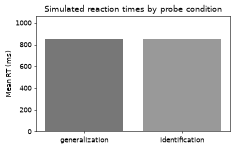

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
conditions = [row['probe_condition'] for row in rt_table]
means = [row['mean_rt_msec'] for row in rt_table]
ax.bar(conditions, means, color=['#777777', '#999999'])
ax.set_ylabel('Mean RT (ms)')
ax.set_title('Simulated reaction times by probe condition')
ax.set_ylim(0, max(means) * 1.25)
plt.show()

## Interpretation

The bot simulation exercises both `identification` and `generalization` probe conditions across set sizes 3, 4, and 5. Identification accuracy is expected to be high because bots choose the correct matching item. Generalization rows show the recorded similarity choices for new probes. Reaction times are populated for every trial from the same event-log pathway used by participant responses.